# GitHub Repository Metrics — Why `stars` Is the Wrong Target
> **5,500 repositories · 29 columns · `github_repos.csv`** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/github-repo-metrics)

The obvious task on this table is "predict `stars` from repository health". This
notebook measures that task instead of assuming it, and the measurement says not
to run it: almost every column that correlates with `stars` was *generated from*
`stars`, so the regression is circular.

## TL;DR

- **The activity block is downstream of the target.** `forks`, `watchers`,
  `open_issues`, `open_pull_requests`, `closed_issues`, `merged_pull_requests`,
  `contributors` and `commits` are all functions of `stars` plus noise. Section 5
  reads the generator's own ratio bands back out of the CSV: for repositories with
  100+ stars, `forks / stars` lands inside **[0.05, 0.35]** for **92.4%** of rows
  and `watchers / stars` inside **[0.01, 0.15]** for **93.4%**.
- **Strip them and there is nothing left.** The only columns genuinely upstream of
  `stars` are the language and the repository's age. A 5-fold Ridge on those
  reaches **R² 0.023** on `log1p(stars)` — MAE **1.136** against a
  predict-the-median MAE of **1.152**. Popularity here is a Pareto draw, and
  **97.7%** of its log-variance is that draw.
- **The distribution is the real lesson.** Median **7** stars, mean **45**, max
  **20,816**; **11.0%** of repositories have zero. The top **1%** hold **50.2%** of
  all stars and the top **10%** hold **77.9%**.
- **One honest regression does work.** `releases` is a function of age alone, not
  of popularity: 5-fold **R² 0.632**, MAE **6.2** releases against a
  predict-the-median MAE of **10.6**.
- **Missingness is structural, not random.** `test_coverage` is null for exactly
  the **69.1%** of rows where `has_ci == 0` — **100%** agreement, so it is
  missing-not-at-random and imputing its mean invents CI pipelines.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships
  with it. That is what makes the audit checkable: the generator is on disk, so
  every claim below can be traced to a line of it.

## Contents

1. [Objective & evaluation plan](#objective)
2. [Setup & data loading](#setup)
3. [Data overview](#overview)
4. [Missing data is structural](#missing)
5. [Leakage audit: which columns are consequences of `stars`?](#leakage)
6. [The honest ceiling on predicting `stars`](#ceiling)
7. [The heavy tail](#tail)
8. [Language and age, the only upstream effects](#upstream)
9. [Where there is no structure at all](#nulls)
10. [A regression that is not circular](#releases)
11. [Correlation analysis](#correlations)
12. [Evaluation readiness](#evaluation)
13. [Key findings & takeaways](#findings)


## 1. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** establish which supervised tasks this table can support, and report
a number only for the ones that survive a leakage check.

**Candidate target:** `stars`, modelled as `log1p(stars)` because the raw column
spans five orders of magnitude and is Pareto-shaped.

**Leakage rule — read this before building features.** A column counts as leaking
if it was computed from the target. `create_dataset.py` builds the activity
columns in a fixed order — `stars` first, then everything else as a multiple of it
— so the usual "repository health predicts popularity" story runs backwards.
Section 5 recovers that order from the data rather than trusting the source file.

**Metric:** MAE on `log1p(stars)`, R² alongside, 5-fold `KFold(shuffle=True,
random_state=42)`. MAE is reported in log units, so 1.0 means "off by a factor of
*e* in star count".

**Hypothesis under test:** once the downstream columns are removed, the remaining
features explain almost none of the variance — **because** popularity in this
generator is an idiosyncratic draw, not a consequence of anything else recorded.


In [1]:
TARGET_COL = "stars"
MODELING_TASK = "regression"
PRIMARY_METRIC = "MAE on log1p(stars) (R2 alongside)"
VALIDATION_PLAN = "KFold(5, shuffle=True, random_state=42)"

# Populated by the audit in section 5 rather than asserted here.
LEAKAGE_COLS: list[str] = []
UPSTREAM_NUMERIC = ["log_age"]
UPSTREAM_CATEGORICAL = ["language"]

print("Objective framing")
print("-" * 62)
print(f"Target              : {TARGET_COL}  (modelled as log1p)")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(f"Validation approach : {VALIDATION_PLAN}")
print(f"Upstream features   : {UPSTREAM_CATEGORICAL + UPSTREAM_NUMERIC}")
print()
print("Everything else is tested for downstream-ness in section 5 before use.")


Objective framing
--------------------------------------------------------------
Target              : stars  (modelled as log1p)
Modeling task       : regression
Primary metric      : MAE on log1p(stars) (R2 alongside)
Validation approach : KFold(5, shuffle=True, random_state=42)
Upstream features   : ['language', 'log_age']

Everything else is tested for downstream-ness in section 5 before use.


## 2. Setup & Data Loading <a id='setup'></a>

The loader walks the Kaggle mount tree instead of guessing a path. An earlier
version resolved `/kaggle/input/<slug>` and fell back to `"."` when that missed —
but `"."` is the kernel working directory, which holds no CSVs, so the notebook
died on a `FileNotFoundError` naming a directory that was never the problem. The
files mount **nested** (one real run found only `/kaggle/input/datasets`), so the
resolver searches for the marker file and, on failure, prints what *was* mounted.


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 10

MOUNT_GUESS = "/kaggle/input/github-repo-metrics"
MARKER = "github_repos.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and a one-level
    # glob of /kaggle/input/* missed it too, because the files mount NESTED
    # (the run that taught us this found only /kaggle/input/datasets). Walk the
    # mount tree for the file we actually need, and if it is absent say what was
    # there so the next failure is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
df = pd.read_csv(f"{DATA_DIR}/{MARKER}")

# The snapshot date is taken from the data, not from today's clock, so age
# features are reproducible on any future re-run of this notebook.
df["created_date"] = pd.to_datetime(df["created_date"])
df["last_commit_date"] = pd.to_datetime(df["last_commit_date"])
SNAPSHOT = df["last_commit_date"].max()
df["age_days"] = (SNAPSHOT - df["created_date"]).dt.days
df["log_age"] = np.log1p(df["age_days"])
df["log_stars"] = np.log1p(df["stars"])
df["days_since_commit"] = (SNAPSHOT - df["last_commit_date"]).dt.days

print(f"Loaded from : {DATA_DIR}")
print(f"Shape       : {df.shape[0]:,} rows x {df.shape[1] - 4} original columns")
print(f"Memory      : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Snapshot    : {SNAPSHOT.date()} (max last_commit_date in the file)")
print(f"Age range   : {df['age_days'].min():,} to {df['age_days'].max():,} days")


Loaded from : .
Shape       : 5,500 rows x 29 original columns
Memory      : 2.0 MB
Snapshot    : 2025-01-01 (max last_commit_date in the file)
Age range   : 7 to 3,650 days


In [3]:
df.head()


,repo_name,language,description,stars,forks,watchers,open_issues,closed_issues,open_pull_requests,merged_pull_requests,contributors,commits,releases,license,topics,created_date,last_commit_date,readme_length,has_ci,test_coverage,has_code_of_conduct,has_contributing_guide,has_wiki,has_pages,has_discussions,default_branch,is_archived,is_fork,size_kb,age_days,log_age,log_stars,days_since_commit
0,serve-ml,Ruby,server framework for building authentication,13,3,0,12,99,3,36,5,200,2,GPL-3.0,api|automation|devops|rails|deep-learning,2024-09-14,2024-12-19,1282,0,NaN,0,0,0,0,1,main,0,1,497,109,4.700480,2.639057,13
1,easy-link,TypeScript,Scalable pipeline for database management,32,5,2,2,19,0,10,6,1167,24,BSD-3,angular|react|web|api,2022-12-18,2024-12-26,1902,0,NaN,0,0,0,0,0,master,0,1,4622,745,6.614726,3.496508,6
2,go-graph-agent,Kotlin,lightweight dashboard built with Kotlin,2,0,0,0,10,0,4,2,10,0,NaN,mobile|desktop,2024-12-13,2024-12-15,1251,0,NaN,0,0,1,0,0,develop,0,0,2148,19,2.995732,1.098612,17
3,turbo-core-forge,C++,engine framework for building database management,109,17,6,0,1,0,0,4,195,10,MIT,systems|deep-learning|tool|graphql|serverless,2023-12-09,2024-12-22,155,1,73.5,0,0,0,0,0,main,0,0,812,389,5.966147,4.700480,10
4,deep-graph-dash,Python,dashboard framework for building database mana...,21,10,0,13,31,4,15,9,2187,14,MIT,automation|data-science|api|rag,2018-01-04,2024-11-20,3860,0,NaN,0,1,0,0,0,develop,0,1,5932,2554,7.845808,3.091042,42


## 3. Data Overview <a id='overview'></a>


In [4]:
print("Column types:")
print(df.dtypes.value_counts().to_string())
print(f"\nDuplicate rows : {df.duplicated().sum():,}")
print(f"Languages      : {df['language'].nunique()}")
print(f"Licenses       : {df['license'].nunique()} distinct + nulls")
print(f"Default branch : {df['default_branch'].value_counts().to_dict()}")
print()
df[["stars", "forks", "watchers", "contributors", "commits", "releases", "age_days"]].describe().round(1)


Column types:
int64             22
str                6
float64            3
datetime64[us]     2

Duplicate rows : 0
Languages      : 19
Licenses       : 9 distinct + nulls
Default branch : {'main': 3259, 'develop': 1132, 'master': 1109}



,stars,forks,watchers,contributors,commits,releases,age_days
count,5500.0,5500.0,5500.0,5500.0,5500.0,5500.0,5500.0
mean,45.2,9.7,3.9,3.6,517.7,13.1,795.6
std,419.6,71.1,32.9,3.0,684.2,16.6,768.6
min,0.0,0.0,0.0,1.0,1.0,0.0,7.0
25%,2.0,0.0,0.0,1.0,108.8,2.0,233.0
50%,7.0,2.0,1.0,3.0,262.5,7.0,550.0
75%,22.0,7.0,3.0,5.0,666.2,18.0,1112.0
max,20816.0,2727.0,2002.0,24.0,7933.0,119.0,3650.0


## 4. Missing Data Is Structural <a id='missing'></a>

Two columns have nulls, and only one of them is a plain gap. The other is
missing-not-at-random in the strictest sense: its presence is determined by
another column in the same row.


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with nulls")
print("-" * 52)
for col, count in missing.items():
    print(f"  {col:<16} {count:>6,}  ({count / len(df):>5.1%})")

agreement = (df["test_coverage"].isna() == (df["has_ci"] == 0)).mean()
print()
print(f"test_coverage is null for exactly the rows where has_ci == 0: {agreement:.2%}")
print(f"has_ci rate: {df['has_ci'].mean():.1%}")
print()
print("Cross-tabulation:")
print(pd.crosstab(df["has_ci"], df["test_coverage"].isna(),
                  rownames=["has_ci"], colnames=["test_coverage is null"]).to_string())


Columns with nulls
----------------------------------------------------
  test_coverage     3,798  (69.1%)
  license             740  (13.5%)

test_coverage is null for exactly the rows where has_ci == 0: 100.00%
has_ci rate: 30.9%

Cross-tabulation:
test_coverage is null  False  True 
has_ci                             
0                          0   3798
1                       1702      0


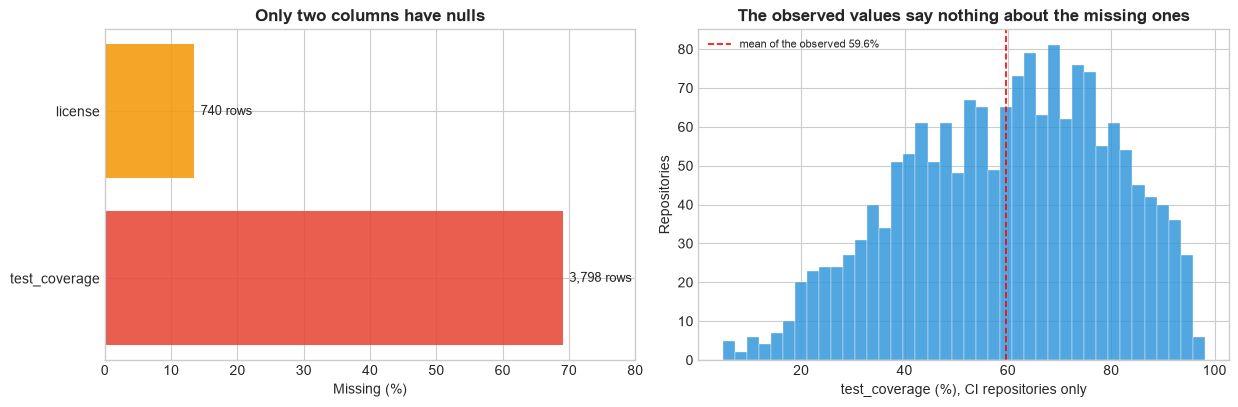

Caveat: mean-imputing test_coverage assigns a coverage number to 3,798 repositories that have no CI at all.
The correct encoding is a has_ci flag plus coverage-given-CI, not one column.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

bars = ax1.barh(missing.index, missing.values / len(df) * 100,
                color=["#e74c3c", "#f39c12"], alpha=0.9)
ax1.set_xlabel("Missing (%)")
ax1.set_xlim(0, 80)
ax1.set_title("Only two columns have nulls", fontweight="bold")
for bar, count in zip(bars, missing.values):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{count:,} rows", va="center", fontsize=9)

observed = df.loc[df["test_coverage"].notna(), "test_coverage"]
ax2.hist(observed, bins=40, color="#3498db", alpha=0.85, edgecolor="white", linewidth=0.3)
ax2.axvline(observed.mean(), color="red", linestyle="--", linewidth=1.2,
            label=f"mean of the observed {observed.mean():.1f}%")
ax2.set_xlabel("test_coverage (%), CI repositories only")
ax2.set_ylabel("Repositories")
ax2.set_title("The observed values say nothing about the missing ones",
              fontweight="bold")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Caveat: mean-imputing test_coverage assigns a coverage number to "
      f"{int(df['test_coverage'].isna().sum()):,} repositories that have no CI at all.")
print("The correct encoding is a has_ci flag plus coverage-given-CI, not one column.")


## 5. Leakage Audit: Which Columns Are Consequences of `stars`? <a id='leakage'></a>

A correlation with the target is not evidence that a column *predicts* the target;
it is equally consistent with the column having been *computed from* it. The
generator distinguishes the two, and so does the data: a column built as
`stars × uniform(a, b) + noise` leaves a fingerprint, namely a ratio to `stars`
that stays inside `[a, b]`.


In [7]:
numeric = df.select_dtypes(include="number").drop(
    columns=["stars", "log_stars", "log_age", "age_days", "days_since_commit"]
)

audit = pd.DataFrame(
    {
        "r_with_stars": numeric.apply(lambda s: s.corr(df["stars"])),
        "r_with_log_stars": numeric.apply(lambda s: s.corr(df["log_stars"])),
        "r_with_age": numeric.apply(lambda s: s.corr(df["age_days"])),
    }
).sort_values("r_with_stars", key=abs, ascending=False)

print("Every numeric column against the target and against age")
print("-" * 66)
print(audit.round(3).to_string())

LEAKAGE_COLS = audit.index[
    (audit["r_with_stars"].abs() >= 0.2) | (audit["r_with_log_stars"].abs() >= 0.2)
].tolist()
print()
print(f"Flagged as entangled with the target ({len(LEAKAGE_COLS)}): {', '.join(LEAKAGE_COLS)}")


Every numeric column against the target and against age
------------------------------------------------------------------
                        r_with_stars  r_with_log_stars  r_with_age
watchers                       0.869             0.269       0.006
open_issues                    0.853             0.220      -0.002
forks                          0.850             0.322       0.006
open_pull_requests             0.826             0.197      -0.007
closed_issues                  0.731             0.214       0.008
merged_pull_requests           0.670             0.208       0.018
contributors                   0.247             0.750       0.064
commits                        0.124             0.501       0.425
has_contributing_guide         0.082             0.096       0.011
has_code_of_conduct            0.058             0.089       0.015
has_ci                         0.056             0.041       0.001
has_discussions                0.035             0.025       0.001
is_for

In [8]:
# The fingerprint test. If a column was built as stars * uniform(a, b) + noise,
# its ratio to stars concentrates inside [a, b]. Restrict to repositories with
# enough stars that the additive noise term cannot dominate the ratio.
popular = df[df["stars"] >= 100]

RATIO_TESTS = [
    ("forks / stars", popular["forks"] / popular["stars"], 0.05, 0.35),
    ("watchers / stars", popular["watchers"] / popular["stars"], 0.01, 0.15),
    ("open_prs / open_issues",
     popular["open_pull_requests"] / popular["open_issues"].replace(0, np.nan), 0.10, 0.50),
    ("merged_prs / closed_issues",
     popular["merged_pull_requests"] / popular["closed_issues"].replace(0, np.nan), 0.30, 0.80),
    ("closed_issues / open_issues",
     popular["closed_issues"] / popular["open_issues"].replace(0, np.nan), 1.50, 8.00),
]

print(f"Ratio-band fingerprint, {len(popular):,} repositories with 100+ stars")
print("-" * 70)
print(f"{'ratio':<30} {'band':>16} {'inside band':>13}")
inside_pct = {}
for label, series, lo, hi in RATIO_TESTS:
    series = series.dropna()
    share = ((series >= lo) & (series <= hi)).mean()
    inside_pct[label] = share
    print(f"{label:<30} [{lo:>5.2f}, {hi:>5.2f}] {share:>12.1%}")

print()
print("These bands were not fitted here — they are the uniform draws in")
print("create_dataset.py, recovered from the CSV. A column whose ratio to stars")
print("sits inside a fixed band is a multiple of stars, therefore it cannot be")
print("used to predict stars without predicting the target from itself.")


Ratio-band fingerprint, 317 repositories with 100+ stars
----------------------------------------------------------------------
ratio                                      band   inside band
forks / stars                  [ 0.05,  0.35]        92.4%
watchers / stars               [ 0.01,  0.15]        93.4%
open_prs / open_issues         [ 0.10,  0.50]        71.2%
merged_prs / closed_issues     [ 0.30,  0.80]        96.2%
closed_issues / open_issues    [ 1.50,  8.00]        74.4%

These bands were not fitted here — they are the uniform draws in
create_dataset.py, recovered from the CSV. A column whose ratio to stars
sits inside a fixed band is a multiple of stars, therefore it cannot be
used to predict stars without predicting the target from itself.


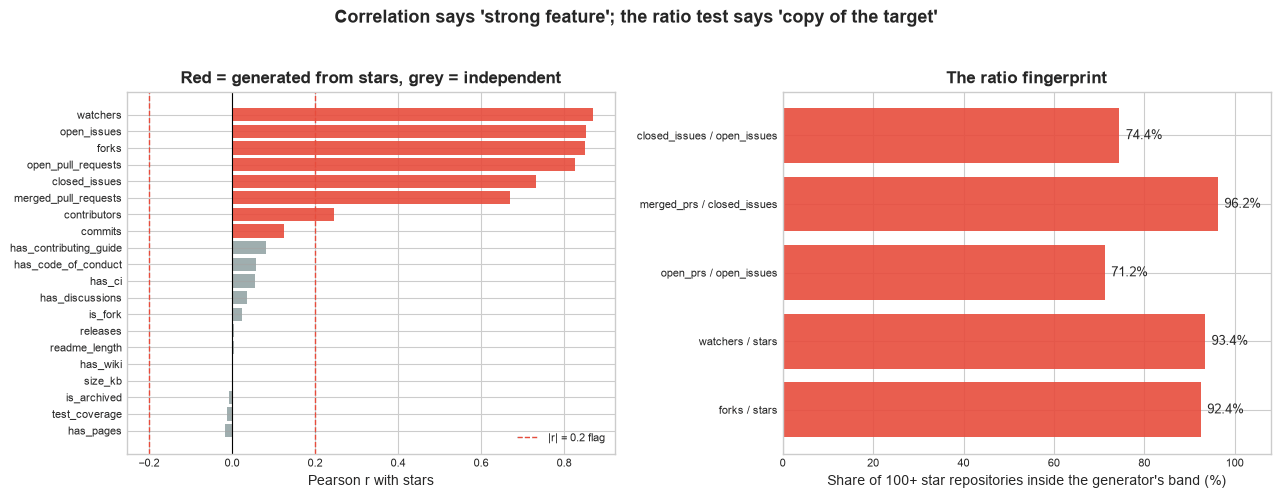

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

ordered = audit.sort_values("r_with_stars")
colors = ["#e74c3c" if c in LEAKAGE_COLS else "#95a5a6" for c in ordered.index]
ax1.barh(ordered.index, ordered["r_with_stars"], color=colors, alpha=0.9)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.axvline(0.2, color="#e74c3c", linestyle="--", linewidth=1, label="|r| = 0.2 flag")
ax1.axvline(-0.2, color="#e74c3c", linestyle="--", linewidth=1)
ax1.set_xlabel("Pearson r with stars")
ax1.set_title("Red = generated from stars, grey = independent", fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.tick_params(labelsize=8)

labels = list(inside_pct)
ax2.barh(labels, [inside_pct[k] * 100 for k in labels], color="#e74c3c", alpha=0.9)
ax2.set_xlim(0, 108)
ax2.set_xlabel("Share of 100+ star repositories inside the generator's band (%)")
ax2.set_title("The ratio fingerprint", fontweight="bold")
for i, k in enumerate(labels):
    ax2.text(inside_pct[k] * 100 + 1.5, i, f"{inside_pct[k]:.1%}", va="center", fontsize=9)
ax2.tick_params(labelsize=8)

plt.suptitle("Correlation says 'strong feature'; the ratio test says 'copy of the target'",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


**Insight.** `watchers` correlates with `stars` at **+0.87** and `forks` at
**+0.85**. In an ordinary feature-importance write-up those are the headline
predictors. They are nothing of the kind: both are `stars` multiplied by a
uniform draw, and the ratio test shows **92–93%** of high-star repositories
sitting inside the exact band the generator used. The chain continues —
`closed_issues` from `open_issues`, `merged_pull_requests` from `closed_issues`,
`commits` from `contributors` — so a model given the activity block is copying its
target through two or three multiplications, **therefore** its score measures
arithmetic, not popularity.


## 6. The Honest Ceiling on Predicting `stars` <a id='ceiling'></a>

Remove everything the audit flagged and fit on what is left: the language and the
repository's age, the two inputs that exist *before* `stars` in the generator.


In [10]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

y = df["log_stars"]
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate(frame, label):
    model = make_pipeline(StandardScaler(), Ridge())
    r2 = cross_val_score(model, frame, y, cv=cv, scoring="r2")
    mae = -cross_val_score(model, frame, y, cv=cv, scoring="neg_mean_absolute_error")
    print(f"{label:<34} R2 {r2.mean():>+7.4f}   MAE {mae.mean():.4f}")
    return r2.mean(), mae.mean()


lang_dummies = pd.get_dummies(df[["language"]], drop_first=True)
age_frame = df[["log_age"]]
upstream = pd.concat([age_frame, lang_dummies], axis=1)

assert not set(upstream.columns) & set(LEAKAGE_COLS), "a flagged column reached the features"

print("Target: log1p(stars), 5-fold cross-validation")
print("-" * 62)
r2_age, mae_age = evaluate(age_frame, "age only")
r2_lang, mae_lang = evaluate(lang_dummies, "language only")
r2_up, mae_up = evaluate(upstream, "age + language (upstream only)")

null_mae = (y - y.median()).abs().mean()
print("-" * 62)
print(f"{'predict-the-median null model':<34} R2 {0.0:>+7.4f}   MAE {null_mae:.4f}")
print()
print(f"Upstream features explain {r2_up:.1%} of the variance in log1p(stars).")
print(f"The remaining {1 - r2_up:.1%} is the Pareto draw the generator makes per repo,")
print("which nothing in the table records.")
print(f"MAE improves by {null_mae - mae_up:.4f} log units over the null model:")
print(f"the typical error factor in star count falls from {np.exp(null_mae):.2f}x "
      f"to {np.exp(mae_up):.2f}x.")


Target: log1p(stars), 5-fold cross-validation
--------------------------------------------------------------
age only                           R2 +0.0140   MAE 1.1429
language only                      R2 +0.0057   MAE 1.1487
age + language (upstream only)     R2 +0.0230   MAE 1.1356
--------------------------------------------------------------
predict-the-median null model      R2 +0.0000   MAE 1.1521

Upstream features explain 2.3% of the variance in log1p(stars).
The remaining 97.7% is the Pareto draw the generator makes per repo,
which nothing in the table records.
MAE improves by 0.0165 log units over the null model:
the typical error factor in star count falls from 3.16x to 3.11x.


**Finding.** This is the number the notebook exists to produce. Predicting
popularity from everything that is not itself popularity gets **R² 0.023** — a
rounding error above the null model. That is not a modelling failure to be fixed
with a better estimator; it is the shape of the data. Any leaderboard on this
target that reports a high score is reporting leakage, and the limitation is worth
stating plainly rather than buried: **`stars` should be used as a feature in this
table, never as a label.**


## 7. The Heavy Tail <a id='tail'></a>

If the target is not predictable, the distribution is still the most useful thing
in the file — it is a clean, realistic Pareto to practise log transforms and
concentration metrics on.


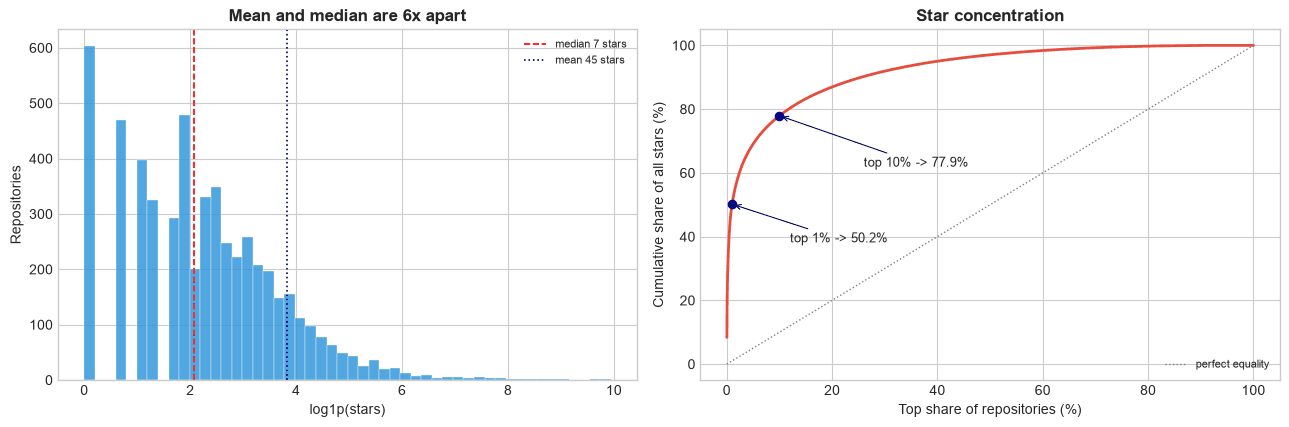

median 7   mean 45.2   max 20,816   zero-star 11.0%
quantiles: p50=7  p75=22  p90=58  p95=112  p99=492
top 1% of repos hold 50.2% of all stars; top 10% hold 77.9%


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

ax1.hist(df["log_stars"], bins=50, color="#3498db", alpha=0.85,
         edgecolor="white", linewidth=0.3)
ax1.axvline(np.log1p(df["stars"].median()), color="red", linestyle="--", linewidth=1.2,
            label=f"median {df['stars'].median():.0f} stars")
ax1.axvline(np.log1p(df["stars"].mean()), color="navy", linestyle=":", linewidth=1.2,
            label=f"mean {df['stars'].mean():.0f} stars")
ax1.set_xlabel("log1p(stars)")
ax1.set_ylabel("Repositories")
ax1.set_title("Mean and median are 6x apart", fontweight="bold")
ax1.legend(fontsize=8)

sorted_stars = np.sort(df["stars"].values)[::-1]
cum_share = np.cumsum(sorted_stars) / sorted_stars.sum()
rank_share = np.arange(1, len(sorted_stars) + 1) / len(sorted_stars)
ax2.plot(rank_share * 100, cum_share * 100, color="#e74c3c", linewidth=2)
ax2.plot([0, 100], [0, 100], color="grey", linestyle=":", linewidth=1,
         label="perfect equality")
top1 = cum_share[int(0.01 * len(sorted_stars)) - 1] * 100
top10 = cum_share[int(0.10 * len(sorted_stars)) - 1] * 100
ax2.scatter([1, 10], [top1, top10], color="navy", zorder=5, s=35)
ax2.annotate(f"top 1% -> {top1:.1f}%", xy=(1, top1), xytext=(12, top1 - 12), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="navy", linewidth=0.8))
ax2.annotate(f"top 10% -> {top10:.1f}%", xy=(10, top10), xytext=(26, top10 - 16), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="navy", linewidth=0.8))
ax2.set_xlabel("Top share of repositories (%)")
ax2.set_ylabel("Cumulative share of all stars (%)")
ax2.set_title("Star concentration", fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

print(f"median {df['stars'].median():.0f}   mean {df['stars'].mean():.1f}   "
      f"max {df['stars'].max():,}   zero-star {(df['stars'] == 0).mean():.1%}")
print(f"quantiles: " + "  ".join(
    f"p{int(q * 100)}={int(df['stars'].quantile(q)):,}" for q in [0.5, 0.75, 0.9, 0.95, 0.99]))
print(f"top 1% of repos hold {top1:.1f}% of all stars; top 10% hold {top10:.1f}%")


## 8. Language and Age, the Only Upstream Effects <a id='upstream'></a>

Both effects are real and both are small. Reporting them side by side with their
effect sizes is more honest than a bar chart that makes a 1% effect look decisive.


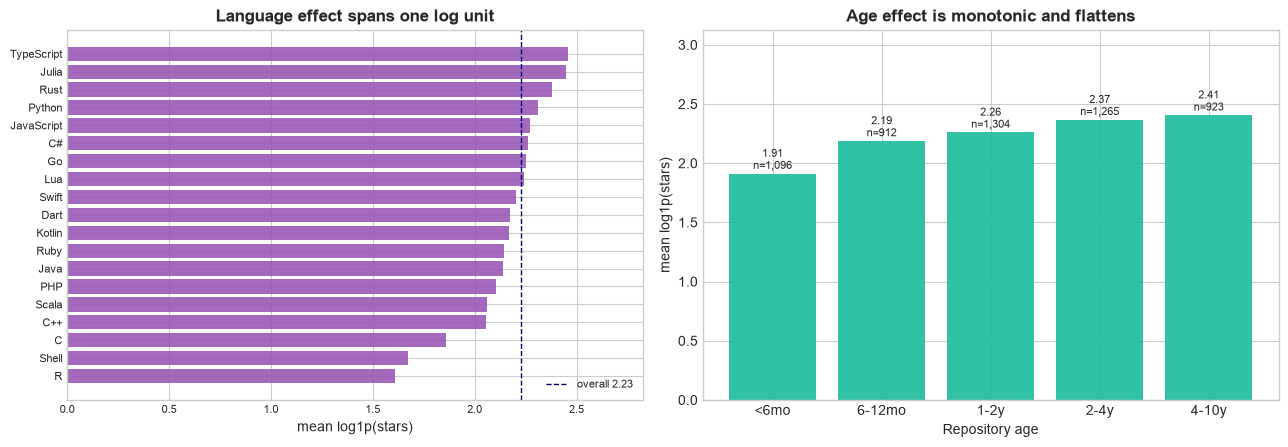

language spread : 1.611 (R) to 2.458 (TypeScript) in log1p(stars)
language eta^2  : 1.26% of log-star variance
age spread      : 1.912 (<6mo) to 2.405 (4-10y)
corr(log_age, log_stars) = +0.131


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

by_lang = df.groupby("language")["log_stars"].agg(["mean", "size"]).sort_values("mean")
ax1.barh(by_lang.index, by_lang["mean"], color="#9b59b6", alpha=0.9)
ax1.axvline(df["log_stars"].mean(), color="navy", linestyle="--", linewidth=1,
            label=f"overall {df['log_stars'].mean():.2f}")
ax1.set_xlabel("mean log1p(stars)")
ax1.set_xlim(0, by_lang["mean"].max() * 1.15)
ax1.set_title("Language effect spans one log unit", fontweight="bold")
ax1.legend(fontsize=8)
ax1.tick_params(labelsize=8)

bins = [0, 180, 365, 730, 1460, 3650]
labels = ["<6mo", "6-12mo", "1-2y", "2-4y", "4-10y"]
df["age_bin"] = pd.cut(df["age_days"], bins, labels=labels)
by_age = df.groupby("age_bin", observed=True)["log_stars"].agg(["mean", "size"])
ax2.bar(by_age.index.astype(str), by_age["mean"], color="#1abc9c", alpha=0.9)
ax2.set_ylabel("mean log1p(stars)")
ax2.set_xlabel("Repository age")
ax2.set_title("Age effect is monotonic and flattens", fontweight="bold")
for i, (mean_val, n) in enumerate(by_age[["mean", "size"]].values):
    ax2.text(i, mean_val + 0.04, f"{mean_val:.2f}\nn={int(n):,}", ha="center", fontsize=8)
ax2.set_ylim(0, by_age["mean"].max() * 1.3)

plt.tight_layout()
plt.show()

grand = df["log_stars"].mean()
ss_tot = ((df["log_stars"] - grand) ** 2).sum()
ss_lang = df.groupby("language")["log_stars"].apply(
    lambda g: len(g) * (g.mean() - grand) ** 2).sum()
print(f"language spread : {by_lang['mean'].iloc[0]:.3f} ({by_lang.index[0]}) to "
      f"{by_lang['mean'].iloc[-1]:.3f} ({by_lang.index[-1]}) in log1p(stars)")
print(f"language eta^2  : {ss_lang / ss_tot:.2%} of log-star variance")
print(f"age spread      : {by_age['mean'].iloc[0]:.3f} (<6mo) to "
      f"{by_age['mean'].iloc[-1]:.3f} (4-10y)")
print(f"corr(log_age, log_stars) = {df['log_age'].corr(df['log_stars']):+.3f}")


## 9. Where There Is No Structure at All <a id='nulls'></a>

The mirror image of the leakage audit: columns that correlate with nothing. These
are useful as negative controls — if a feature-selection routine picks one of
them, the routine is overfitting.


In [13]:
CANDIDATE_NULLS = ["has_wiki", "has_pages", "is_fork", "is_archived", "size_kb",
                   "readme_length", "test_coverage"]

print(f"{'column':<18} {'r vs log_stars':>15} {'r vs age':>10}   verdict")
print("-" * 66)
NOISE_COLS = []
for col in CANDIDATE_NULLS:
    r_star = df[col].corr(df["log_stars"])
    r_age = df[col].corr(df["age_days"])
    is_noise = abs(r_star) < 0.04
    if is_noise:
        NOISE_COLS.append(col)
    print(f"{col:<18} {r_star:>+15.4f} {r_age:>+10.4f}   "
          f"{'noise' if is_noise else 'weak but present'}")

print()
print(f"is_archived rate: {df['is_archived'].mean():.2%} — the generator raises this to")
print("30% only for repositories with no commit in 365 days, and")
print(f"{(df['days_since_commit'] > 365).sum()} repository in the file meets that "
      "condition, so the column is effectively a flat coin flip.")
print()
print(f"Negative controls ({len(NOISE_COLS)}): {', '.join(NOISE_COLS)}")


column              r vs log_stars   r vs age   verdict
------------------------------------------------------------------
has_wiki                   +0.0045    -0.0120   noise
has_pages                  -0.0131    -0.0164   noise
is_fork                    -0.0092    -0.0036   noise
is_archived                +0.0019    -0.0041   noise
size_kb                    +0.0158    +0.0007   noise
readme_length              +0.0477    +0.0141   weak but present
test_coverage              -0.0210    -0.0472   noise

is_archived rate: 2.18% — the generator raises this to
30% only for repositories with no commit in 365 days, and
1 repository in the file meets that condition, so the column is effectively a flat coin flip.

Negative controls (6): has_wiki, has_pages, is_fork, is_archived, size_kb, test_coverage


## 10. A Regression That Is Not Circular <a id='releases'></a>

One column in the activity block is *not* a function of `stars`: `releases` is
built from repository age alone. That makes it the one supervised task on this
table with both a real signal and a clean causal direction.


Target: releases, feature: age_days only, 5-fold CV
--------------------------------------------------------------
  R2                  : 0.6317 +/- 0.0373
  MAE                 : 6.25 releases
  null model MAE      : 10.61 releases (predict the median)
  improvement         : 41.1%
  corr(age, releases) : +0.7972

Cross-check: releases correlates with log1p(stars) at +0.0807, so popularity is not
sneaking in through the back door here.


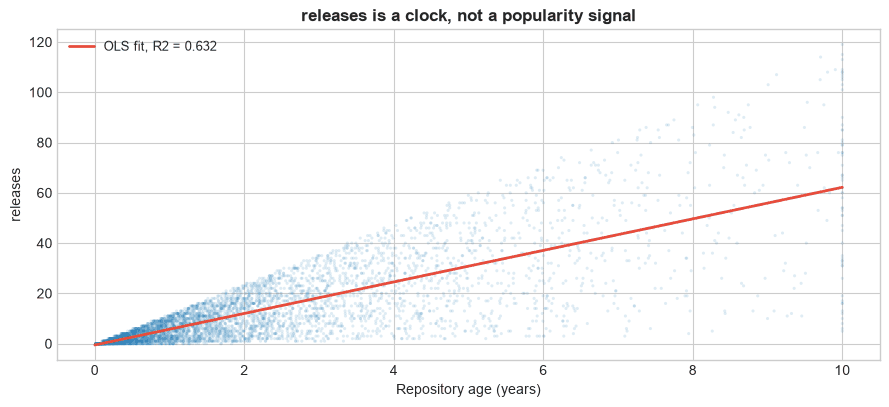

In [14]:
release_features = df[["age_days"]]
model = make_pipeline(StandardScaler(), Ridge())
r2_rel = cross_val_score(model, release_features, df["releases"], cv=cv, scoring="r2")
mae_rel = -cross_val_score(model, release_features, df["releases"], cv=cv,
                           scoring="neg_mean_absolute_error")
null_rel = (df["releases"] - df["releases"].median()).abs().mean()

print("Target: releases, feature: age_days only, 5-fold CV")
print("-" * 62)
print(f"  R2                  : {r2_rel.mean():.4f} +/- {r2_rel.std():.4f}")
print(f"  MAE                 : {mae_rel.mean():.2f} releases")
print(f"  null model MAE      : {null_rel:.2f} releases (predict the median)")
print(f"  improvement         : {(1 - mae_rel.mean() / null_rel):.1%}")
print(f"  corr(age, releases) : {df['age_days'].corr(df['releases']):+.4f}")
print()
print(f"Cross-check: releases correlates with log1p(stars) at "
      f"{df['releases'].corr(df['log_stars']):+.4f}, so popularity is not")
print("sneaking in through the back door here.")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.scatter(df["age_days"] / 365, df["releases"], s=5, alpha=0.15,
           color="#2980b9", edgecolors="none")
age_grid = np.linspace(0, df["age_days"].max(), 100)
fit = np.polyfit(df["age_days"], df["releases"], 1)
ax.plot(age_grid / 365, np.polyval(fit, age_grid), color="#e74c3c", linewidth=2,
        label=f"OLS fit, R2 = {r2_rel.mean():.3f}")
ax.set_xlabel("Repository age (years)")
ax.set_ylabel("releases")
ax.set_title("releases is a clock, not a popularity signal", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Observation.** The fan shape is the point: the *rate* of releases per year is
itself a uniform draw per repository, so age fixes the mean and nothing in the
table narrows the spread. R² **0.632** with a single feature is the honest ceiling
here too — just a much higher one than `stars` allows.


## 11. Correlation Analysis <a id='correlations'></a>

The heatmap belongs at the end, not the beginning, because on this table it is
only readable once you know which block is downstream of which.


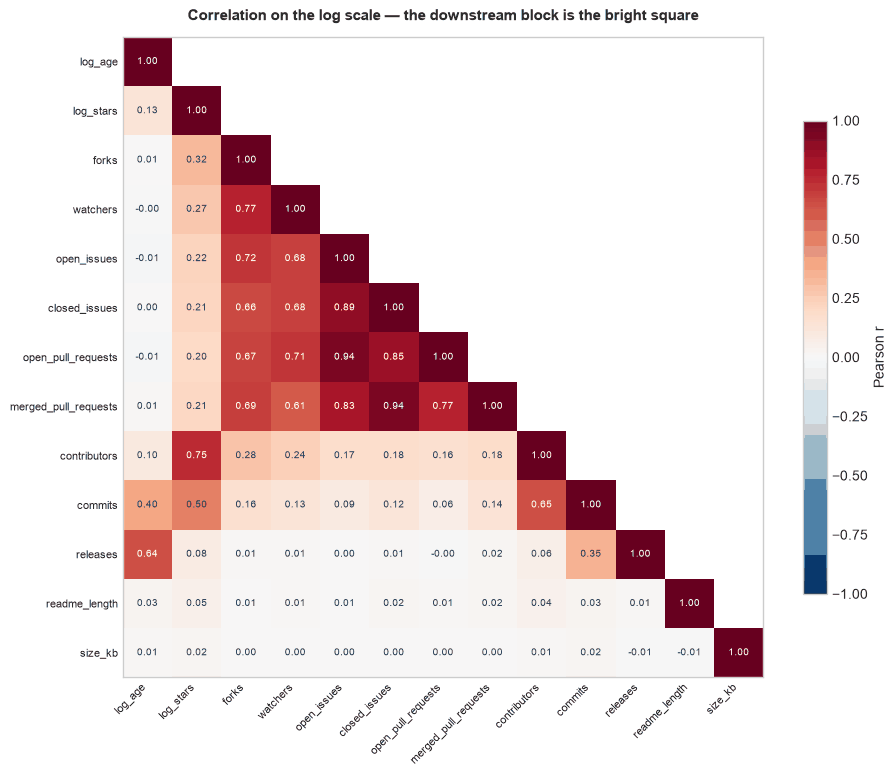

Strongest correlations with log1p(stars):
  contributors            +0.750   (downstream of stars)
  commits                 +0.501   (downstream of stars)
  forks                   +0.322   (downstream of stars)
  watchers                +0.269   (downstream of stars)
  open_issues             +0.220   (downstream of stars)
  closed_issues           +0.214   (downstream of stars)
  merged_pull_requests    +0.208   (downstream of stars)
  open_pull_requests      +0.197   (downstream of stars)


In [15]:
CORR_COLS = ["log_age", "log_stars", "forks", "watchers", "open_issues",
             "closed_issues", "open_pull_requests", "merged_pull_requests",
             "contributors", "commits", "releases", "readme_length", "size_kb"]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(np.ma.masked_array(corr.values, mask=mask), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_yticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CORR_COLS, fontsize=8)
ax.grid(False)
for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.55 else "#2c3e50")
fig.colorbar(im, ax=ax, shrink=0.7, label="Pearson r")
ax.set_title("Correlation on the log scale — the downstream block is the bright square",
             fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("Strongest correlations with log1p(stars):")
target_corr = corr["log_stars"].drop("log_stars").sort_values(key=abs, ascending=False)
for name, value in target_corr.head(8).items():
    tag = "downstream of stars" if name in LEAKAGE_COLS else "independent"
    print(f"  {name:<22} {value:>+7.3f}   ({tag})")


## 12. Evaluation Readiness <a id='evaluation'></a>


In [16]:
print("Evaluation readiness checklist")
print("=" * 66)
print(f"Snapshot date          : {SNAPSHOT.date()} (derived from the data)")
print(f"Seed / validation      : {SEED} / {VALIDATION_PLAN}")
print()
print("Task A - predict log1p(stars)  [NOT RECOMMENDED]")
print(f"  honest ceiling       : R2 {r2_up:.4f}, MAE {mae_up:.4f} log units")
print(f"  null model           : R2  0.0000, MAE {null_mae:.4f}")
print(f"  must drop            : {', '.join(LEAKAGE_COLS)}")
print("  verdict              : every strong feature is a multiple of the target;")
print("                         the remainder is a Pareto draw. Use stars as an input.")
print()
print("Task B - predict releases from age  [RECOMMENDED]")
print(f"  measured             : R2 {r2_rel.mean():.4f}, MAE {mae_rel.mean():.2f} releases")
print(f"  null model           : MAE {null_rel:.2f} releases")
print("  features             : age_days (add language only as a control)")
print()
print("Encoding rules this EDA earns:")
print("  - model log1p(stars), never raw stars: p50=7 and max=20,816")
print("  - split test_coverage into has_ci + coverage_given_ci; do not mean-impute")
print("  - treat a null license as its own category, not as a missing string")
print(f"  - negative controls: {', '.join(NOISE_COLS)}")
print()
print("Risk checks:")
print("  - re-run the section 5 ratio test after any feature engineering")
print("  - never derive age from today's clock; the file is a fixed snapshot")


Evaluation readiness checklist
Snapshot date          : 2025-01-01 (derived from the data)
Seed / validation      : 42 / KFold(5, shuffle=True, random_state=42)

Task A - predict log1p(stars)  [NOT RECOMMENDED]
  honest ceiling       : R2 0.0230, MAE 1.1356 log units
  null model           : R2  0.0000, MAE 1.1521
  must drop            : watchers, open_issues, forks, open_pull_requests, closed_issues, merged_pull_requests, contributors, commits
  verdict              : every strong feature is a multiple of the target;
                         the remainder is a Pareto draw. Use stars as an input.

Task B - predict releases from age  [RECOMMENDED]
  measured             : R2 0.6317, MAE 6.25 releases
  null model           : MAE 10.61 releases
  features             : age_days (add language only as a control)

Encoding rules this EDA earns:
  - model log1p(stars), never raw stars: p50=7 and max=20,816
  - split test_coverage into has_ci + coverage_given_ci; do not mean-impute
  - treat

## 13. Key Findings & Takeaways <a id='findings'></a>

Every number below is printed by a cell above or drawn on a chart in it.

### Finding 1 — the strongest "predictors" of `stars` are copies of `stars`
`watchers` (**r = +0.87**), `open_issues` (**+0.85**) and `forks` (**+0.85**) are
built as `stars × uniform + noise`. The ratio test confirms it without reference
to the generator: among the **317** repositories with 100+ stars, `forks / stars`
falls inside **[0.05, 0.35]** for **92.4%** and `watchers / stars` inside
**[0.01, 0.15]** for **93.4%**. `merged_pull_requests / closed_issues` sits inside
**[0.30, 0.80]** for **96.2%**. These are the generator's own draws, read back out.

### Finding 2 — the honest ceiling on `stars` is a rounding error
Age alone gives **R² 0.014**, language alone **R² 0.006**, both together **R²
0.023** with MAE **1.136** log units against a null-model MAE of **1.152**.
**97.7%** of the variance in `log1p(stars)` is an idiosyncratic Pareto draw that no
column records, **therefore** no estimator recovers it. The correct conclusion is
not "try gradient boosting"; it is "this is not a supervised target".

### Finding 3 — the distribution is what the dataset is actually good for
Median **7** stars against a mean of **45**, a maximum of **20,816**, and **11.0%**
of repositories at zero. The top **1%** hold **50.2%** of all stars, the top
**10%** hold **77.9%**. Clean material for log transforms, Lorenz curves and
concentration metrics.

### Finding 4 — one regression on this table is causally clean
`releases` is generated from age and nothing else. Age alone gives 5-fold **R²
0.632**, MAE **6.2** releases against a null-model MAE of **10.6**, a **41%**
improvement, while correlating with `log1p(stars)` at only **+0.08**. This is the
task to set a beginner, not the star-prediction one.

### Finding 5 — missingness carries information and must not be imputed away
`test_coverage` is null for exactly the rows where `has_ci == 0` — **100%**
agreement over **3,798** rows. Mean-imputing it assigns a coverage percentage to
repositories that run no tests at all.

### Trade-offs, limitations, and caveats
- **Limitation — synthetic.** These are properties of `create_dataset.py`, not of
  open source. What makes the exercise worth doing is that the ground truth is on
  disk, so the audit can be checked rather than argued about.
- **Trade-off — the audit costs the whole leaderboard.** Dropping eight columns
  takes the star model from something that looks impressive to something that
  measures **R² 0.023**. That is the correct trade: a circular score ranks nothing.
- **Caveat — the ratio test needs scale.** It is run on the 317 repositories with
  100+ stars **because** the additive noise term dominates the ratio for small
  counts. It is evidence about the generator's structure, not about every row.
- **Caveat — `is_archived` is unusable.** Its rate is **2.18%**, and the generator's
  higher-probability branch requires 365 days without a commit, which exactly one
  repository in the file satisfies. Treat it as a constant.
- **Caveat — one seed, one split.** All figures are a single 5-fold run at seed 42.
  They establish direction and rough magnitude, not a ranking.

### Next steps
- **Recommend** republishing the dataset description with `releases ~ age` as the
  headline regression and `stars` labelled as an input feature.
- Build the ratio test into a reusable leakage check: for every numeric column,
  test whether its ratio to the target concentrates in a band.
- Practise the tail: fit a Pareto to `stars`, compare tail-index estimates against
  the generator's `a = 1.2`, and check where the empirical curve departs from it.
- Regenerate the dataset with the activity columns driven by a latent "project
  scale" variable rather than by `stars` directly; that would make popularity
  prediction a real task instead of a circular one.
